In [1]:
!pip install datasets transformers scikit-learn

In [2]:
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, DefaultDataCollator
import torch
import numpy as np
from sklearn.metrics import f1_score

In [3]:
dataset = load_dataset("google-research-datasets/go_emotions", "simplified")

num_labels = 28

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [4]:
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

def tokenize(example):
    return tokenizer(
        example["text"],
        truncation=True,
        padding="max_length",
        max_length=128,
    )

dataset = dataset.map(tokenize, batched=True)

Map:   0%|          | 0/43410 [00:00<?, ? examples/s]

Map:   0%|          | 0/5426 [00:00<?, ? examples/s]

Map:   0%|          | 0/5427 [00:00<?, ? examples/s]

In [5]:
def to_multi_hot(example):
    multi_hot = np.zeros(num_labels, dtype=np.float32)
    multi_hot[example["labels"]] = 1.0
    example["labels"] = multi_hot
    return example

dataset = dataset.map(to_multi_hot)

Map:   0%|          | 0/43410 [00:00<?, ? examples/s]

Map:   0%|          | 0/5426 [00:00<?, ? examples/s]

Map:   0%|          | 0/5427 [00:00<?, ? examples/s]

In [6]:
dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "labels"]
)

In [7]:
train_dataset = dataset["train"].select(range(2000))
val_dataset = dataset["validation"].select(range(500))

print(len(train_dataset), len(val_dataset))

2000 500


In [8]:
print(dataset["train"][0]["labels"])
print(type(dataset["train"][0]["labels"]))

ImportError: cannot import name 'VideoReader' from 'torchvision.io' (/usr/local/lib/python3.12/dist-packages/torchvision/io/__init__.py)

In [9]:
dataset_py = dataset.with_format("python")

print(dataset_py["train"][0]["labels"])
print(type(dataset_py["train"][0]["labels"]))

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]
<class 'list'>


In [10]:
model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=num_labels,
    problem_type="multi_label_classification"
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [11]:
label_names = dataset["train"].features["labels"].feature.names

for i, name in enumerate(label_names):
    print(i, name)

0 admiration
1 amusement
2 anger
3 annoyance
4 approval
5 caring
6 confusion
7 curiosity
8 desire
9 disappointment
10 disapproval
11 disgust
12 embarrassment
13 excitement
14 fear
15 gratitude
16 grief
17 joy
18 love
19 nervousness
20 optimism
21 pride
22 realization
23 relief
24 remorse
25 sadness
26 surprise
27 neutral


In [12]:
tail_labels = [16, 21, 23, 19, 12, 24, 14, 8]

In [13]:
def tail_recall(labels, preds):
    recalls = []
    for i in tail_labels:
        true = labels[:, i]
        pred = preds[:, i]

        tp = ((true == 1) & (pred == 1)).sum()
        fn = ((true == 1) & (pred == 0)).sum()

        if tp + fn > 0:
            recalls.append(tp / (tp + fn))

    return np.mean(recalls) if recalls else 0


def compute_metrics(eval_pred):
    logits, labels = eval_pred

    probs = 1 / (1 + np.exp(-logits))  # sigmoid
    preds = (probs > 0.5).astype(int)

    micro_f1 = f1_score(labels, preds, average="micro", zero_division=0)
    macro_f1 = f1_score(labels, preds, average="macro", zero_division=0)
    tail = tail_recall(labels, preds)

    return {
        "micro_f1": micro_f1,
        "macro_f1": macro_f1,
        "tail_recall": tail,
    }

In [14]:
data_collator = DefaultDataCollator(return_tensors="pt")

class MultiLabelCollator:
    def __call__(self, features):
        batch = data_collator(features)
        batch["labels"] = batch["labels"].float()
        return batch

collator = MultiLabelCollator()

In [15]:
training_args = TrainingArguments(
    output_dir="./results",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    logging_steps=50,
    report_to="none",
)

In [16]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    data_collator=collator,
)

In [18]:
import sys

for mod in list(sys.modules.keys()):
    if mod.startswith("torchvision"):
        del sys.modules[mod]

print("torchvision removed from current session modules if it was loaded.")

torchvision removed from current session modules if it was loaded.


In [19]:
trainer.train()

Step,Training Loss
50,0.352322
100,0.164413
150,0.151569
200,0.148395
250,0.153008
300,0.146315
350,0.140711


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=375, training_loss=0.17733295059204102, metrics={'train_runtime': 70.7398, 'train_samples_per_second': 84.818, 'train_steps_per_second': 5.301, 'total_flos': 198793230336000.0, 'train_loss': 0.17733295059204102, 'epoch': 3.0})

In [20]:
trainer.evaluate()

{'eval_loss': 0.1478981375694275,
 'eval_micro_f1': 0.013071895424836602,
 'eval_macro_f1': 0.0017316017316017316,
 'eval_tail_recall': 0.0,
 'eval_runtime': 1.9363,
 'eval_samples_per_second': 258.226,
 'eval_steps_per_second': 16.526,
 'epoch': 3.0}

In [21]:
pred_output = trainer.predict(val_dataset)

logits = pred_output.predictions
labels = pred_output.label_ids

probs = 1 / (1 + np.exp(-logits))

print(probs[:5])
print("max prob:", probs.max())
print("mean prob:", probs.mean())

[[0.13335069 0.0586767  0.04947948 0.05969653 0.08325461 0.02984327
  0.03367404 0.04688996 0.01872066 0.0404124  0.05555152 0.02422829
  0.0116209  0.02006928 0.01864064 0.08087686 0.01293252 0.04472002
  0.07535753 0.00951678 0.05144894 0.00967114 0.02567356 0.01244048
  0.01831101 0.03879073 0.03841021 0.1766184 ]
 [0.06640373 0.05288005 0.03949372 0.05824411 0.07112817 0.02261491
  0.02933131 0.04714625 0.01271343 0.0379816  0.04925951 0.01516827
  0.00825555 0.01122693 0.01412203 0.03224746 0.01045621 0.02661076
  0.04137586 0.00596936 0.03667689 0.00705842 0.0220204  0.00956911
  0.01276518 0.03212525 0.0261542  0.40364242]
 [0.11159744 0.0528916  0.0415338  0.05302304 0.0730717  0.02432762
  0.02839955 0.04136768 0.01550275 0.03604397 0.04884723 0.0191974
  0.00895822 0.01651209 0.01515827 0.06472998 0.01113358 0.0378944
  0.06354748 0.00717907 0.04262899 0.00759329 0.02190507 0.01027223
  0.01410281 0.03354798 0.03244418 0.20357865]
 [0.06524492 0.05290666 0.03765205 0.05812223

In [22]:
from sklearn.metrics import f1_score

thresholds = [0.05, 0.1, 0.15, 0.2, 0.25, 0.3]

for t in thresholds:
    preds = (probs > t).astype(int)

    micro = f1_score(labels, preds, average="micro", zero_division=0)
    macro = f1_score(labels, preds, average="macro", zero_division=0)
    #tail = tail_recall(labels, preds, tail_labels)
    tail = tail_recall(labels, preds)

    print(f"Threshold: {t}")
    print(f"  Micro-F1: {micro:.4f}")
    print(f"  Macro-F1: {macro:.4f}")
    print(f"  Tail Recall: {tail:.4f}")
    print()

Threshold: 0.05
  Micro-F1: 0.1783
  Macro-F1: 0.0715
  Tail Recall: 0.0000

Threshold: 0.1
  Micro-F1: 0.3045
  Macro-F1: 0.0488
  Tail Recall: 0.0000

Threshold: 0.15
  Micro-F1: 0.3552
  Macro-F1: 0.0521
  Tail Recall: 0.0000

Threshold: 0.2
  Micro-F1: 0.3515
  Macro-F1: 0.0556
  Tail Recall: 0.0000

Threshold: 0.25
  Micro-F1: 0.3290
  Macro-F1: 0.0523
  Tail Recall: 0.0000

Threshold: 0.3
  Micro-F1: 0.2917
  Macro-F1: 0.0384
  Tail Recall: 0.0000



In [23]:
fine_thresholds = [0.05, 0.06, 0.07, 0.08, 0.09, 0.10]

print("=== Fine-grained threshold sweep ===\n")

for t in fine_thresholds:
    preds = (probs > t).astype(int)

    micro = f1_score(labels, preds, average="micro", zero_division=0)
    macro = f1_score(labels, preds, average="macro", zero_division=0)
    #tail = tail_recall(labels, preds, tail_labels)
    tail = tail_recall(labels, preds)

    print(f"Threshold: {t:.2f}")
    print(f"  Micro-F1: {micro:.4f}")
    print(f"  Macro-F1: {macro:.4f}")
    print(f"  Tail Recall: {tail:.4f}")
    print()

=== Fine-grained threshold sweep ===

Threshold: 0.05
  Micro-F1: 0.1783
  Macro-F1: 0.0715
  Tail Recall: 0.0000

Threshold: 0.06
  Micro-F1: 0.2045
  Macro-F1: 0.0628
  Tail Recall: 0.0000

Threshold: 0.07
  Micro-F1: 0.2495
  Macro-F1: 0.0620
  Tail Recall: 0.0000

Threshold: 0.08
  Micro-F1: 0.2699
  Macro-F1: 0.0533
  Tail Recall: 0.0000

Threshold: 0.09
  Micro-F1: 0.2895
  Macro-F1: 0.0471
  Tail Recall: 0.0000

Threshold: 0.10
  Micro-F1: 0.3045
  Macro-F1: 0.0488
  Tail Recall: 0.0000



In [24]:
# Define per-class thresholds

default_threshold = 0.1
tail_threshold = 0.05

threshold_vector = np.full(num_labels, default_threshold)
for i in tail_labels:
    threshold_vector[i] = tail_threshold

print("Threshold vector:")
print(threshold_vector)

Threshold vector:
[0.1  0.1  0.1  0.1  0.1  0.1  0.1  0.1  0.05 0.1  0.1  0.1  0.05 0.1
 0.05 0.1  0.05 0.1  0.1  0.05 0.1  0.05 0.1  0.05 0.05 0.1  0.1  0.1 ]


In [25]:
# Apply per-class thresholds

preds = (probs > threshold_vector).astype(int)

micro = f1_score(labels, preds, average="micro", zero_division=0)
macro = f1_score(labels, preds, average="macro", zero_division=0)
#tail = tail_recall(labels, preds, tail_labels)
tail = tail_recall(labels, preds)

print("=== Per-class threshold results ===")
print(f"Micro-F1: {micro:.4f}")
print(f"Macro-F1: {macro:.4f}")
print(f"Tail Recall: {tail:.4f}")

=== Per-class threshold results ===
Micro-F1: 0.3045
Macro-F1: 0.0488
Tail Recall: 0.0000


In [26]:
# ==========================================
# EXPERIMENT 10 – CLASS-WEIGHTED LOSS
# ==========================================

In [27]:
# Make sure we use the larger subset setting here
train_dataset = dataset["train"].select(range(5000))
val_dataset = dataset["validation"].select(range(500))

print("Train size:", len(train_dataset))
print("Validation size:", len(val_dataset))

Train size: 5000
Validation size: 500


In [28]:
# Build label matrix from the current training subset
train_label_matrix = np.stack([train_dataset[i]["labels"].numpy() for i in range(len(train_dataset))])

label_counts = train_label_matrix.sum(axis=0)
num_samples = train_label_matrix.shape[0]

print("Label counts:")
for i, count in enumerate(label_counts):
    print(i, label_names[i], int(count))

# BCEWithLogitsLoss pos_weight
# Higher weight for rarer positive labels
pos_weight = (num_samples - label_counts) / (label_counts + 1e-6)
pos_weight = torch.tensor(pos_weight, dtype=torch.float)

print("\nPos weights:")
print(pos_weight)

Label counts:
0 admiration 506
1 amusement 269
2 anger 184
3 annoyance 260
4 approval 316
5 caring 119
6 confusion 148
7 curiosity 221
8 desire 78
9 disappointment 163
10 disapproval 255
11 disgust 90
12 embarrassment 28
13 excitement 100
14 fear 67
15 gratitude 319
16 grief 12
17 joy 187
18 love 253
19 nervousness 23
20 optimism 182
21 pride 9
22 realization 120
23 relief 18
24 remorse 69
25 sadness 162
26 surprise 125
27 neutral 1646

Pos weights:
tensor([  8.8814,  17.5874,  26.1739,  18.2308,  14.8228,  41.0168,  32.7838,
         21.6244,  63.1026,  29.6748,  18.6078,  54.5556, 177.5714,  49.0000,
         73.6269,  14.6740, 415.6666,  25.7380,  18.7628, 216.3913,  26.4725,
        554.5555,  40.6667, 276.7778,  71.4638,  29.8642,  39.0000,   2.0377])


In [29]:
from transformers import Trainer

class WeightedTrainer(Trainer):
    def __init__(self, pos_weight=None, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.pos_weight = pos_weight

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits

        loss_fct = torch.nn.BCEWithLogitsLoss(
            pos_weight=self.pos_weight.to(logits.device)
        )
        loss = loss_fct(logits, labels)

        return (loss, outputs) if return_outputs else loss

In [30]:
model_w = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=num_labels,
    problem_type="multi_label_classification"
)

training_args_w = TrainingArguments(
    output_dir="./results_weighted",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    logging_steps=50,
    report_to="none",
)

trainer_w = WeightedTrainer(
    model=model_w,
    args=training_args_w,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    data_collator=collator,
    pos_weight=pos_weight,
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [31]:
trainer_w.train()
trainer_w.evaluate()

Step,Training Loss
50,1.289800
100,1.340126
150,1.235260
200,1.075563
250,1.047292
300,1.103287
350,0.952043
400,0.920151
450,0.803037
500,0.778451


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'eval_loss': 0.9667742848396301,
 'eval_micro_f1': 0.3787878787878788,
 'eval_macro_f1': 0.34883919716198486,
 'eval_tail_recall': 0.5966346153846154,
 'eval_runtime': 2.1556,
 'eval_samples_per_second': 231.955,
 'eval_steps_per_second': 14.845,
 'epoch': 3.0}

In [32]:
pred_output_w = trainer_w.predict(val_dataset)

logits_w = pred_output_w.predictions
labels_w = pred_output_w.label_ids

probs_w = 1 / (1 + np.exp(-logits_w))

print(probs_w[:5])
print("max prob:", probs_w.max())
print("mean prob:", probs_w.mean())

[[0.26587316 0.18658505 0.11706838 0.17056862 0.25374943 0.09347349
  0.8687728  0.9340148  0.1580962  0.1432304  0.1921395  0.09840749
  0.14102091 0.40230963 0.03811868 0.07631306 0.06490738 0.16279027
  0.18023261 0.06265624 0.23779352 0.03685084 0.4034719  0.08985846
  0.06723046 0.11270285 0.7596464  0.40083393]
 [0.11566078 0.02573538 0.33869296 0.60763115 0.5051265  0.7529248
  0.1678929  0.09374679 0.0747373  0.1558843  0.4880279  0.18325144
  0.03462455 0.04263944 0.08859479 0.05716897 0.07527474 0.02795125
  0.04338896 0.04006086 0.2073382  0.02390151 0.24750857 0.037925
  0.04055366 0.07316477 0.04299979 0.7413696 ]
 [0.41100797 0.4979206  0.2238125  0.30293274 0.27923304 0.3746354
  0.1981423  0.14564429 0.18870005 0.68675864 0.39398563 0.39784175
  0.54244167 0.2767911  0.24213874 0.3041613  0.70315224 0.43922216
  0.29534003 0.2878393  0.3470283  0.41232863 0.50290036 0.39244947
  0.80632603 0.9364017  0.20405327 0.23135687]
 [0.06012489 0.08128701 0.295912   0.64167553 0

In [33]:
thresholds = [0.05, 0.1, 0.15, 0.2, 0.25, 0.3]

for t in thresholds:
    preds_w = (probs_w > t).astype(int)

    micro = f1_score(labels_w, preds_w, average="micro", zero_division=0)
    macro = f1_score(labels_w, preds_w, average="macro", zero_division=0)
    tail = tail_recall(labels_w, preds_w)

    print(f"Threshold: {t}")
    print(f"  Micro-F1: {micro:.4f}")
    print(f"  Macro-F1: {macro:.4f}")
    print(f"  Tail Recall: {tail:.4f}")
    print()

Threshold: 0.05
  Micro-F1: 0.0981
  Macro-F1: 0.0868
  Tail Recall: 0.9688

Threshold: 0.1
  Micro-F1: 0.1299
  Macro-F1: 0.1120
  Tail Recall: 0.9437

Threshold: 0.15
  Micro-F1: 0.1577
  Macro-F1: 0.1364
  Tail Recall: 0.8031

Threshold: 0.2
  Micro-F1: 0.1898
  Macro-F1: 0.1677
  Tail Recall: 0.7625

Threshold: 0.25
  Micro-F1: 0.2202
  Macro-F1: 0.1978
  Tail Recall: 0.7469

Threshold: 0.3
  Micro-F1: 0.2531
  Macro-F1: 0.2315
  Tail Recall: 0.7469



In [34]:
high_thresholds = [0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.7]

for t in high_thresholds:
    preds_w = (probs_w > t).astype(int)

    micro = f1_score(labels_w, preds_w, average="micro", zero_division=0)
    macro = f1_score(labels_w, preds_w, average="macro", zero_division=0)
    tail = tail_recall(labels_w, preds_w)

    print(f"Threshold: {t}")
    print(f"  Micro-F1: {micro:.4f}")
    print(f"  Macro-F1: {macro:.4f}")
    print(f"  Tail Recall: {tail:.4f}")
    print()

Threshold: 0.35
  Micro-F1: 0.2875
  Macro-F1: 0.2676
  Tail Recall: 0.7469

Threshold: 0.4
  Micro-F1: 0.3192
  Macro-F1: 0.2952
  Tail Recall: 0.7469

Threshold: 0.45
  Micro-F1: 0.3479
  Macro-F1: 0.3210
  Tail Recall: 0.5966

Threshold: 0.5
  Micro-F1: 0.3788
  Macro-F1: 0.3488
  Tail Recall: 0.5966

Threshold: 0.55
  Micro-F1: 0.4090
  Macro-F1: 0.3782
  Tail Recall: 0.5966

Threshold: 0.6
  Micro-F1: 0.4330
  Macro-F1: 0.3940
  Tail Recall: 0.5966

Threshold: 0.7
  Micro-F1: 0.4554
  Macro-F1: 0.4158
  Tail Recall: 0.5341



In [35]:
# ==========================================
# EXPERIMENT 12 – OVERSAMPLING + WEIGHTED LOSS
# ==========================================

In [36]:
from datasets import concatenate_datasets

# Use the same 5000-sample base subset
train_dataset = dataset["train"].select(range(5000))
val_dataset = dataset["validation"].select(range(500))

tail_train_indices = []

for i in range(len(train_dataset)):
    label_vector = train_dataset[i]["labels"].numpy()
    if any(label_vector[idx] == 1 for idx in tail_labels):
        tail_train_indices.append(i)

tail_subset = train_dataset.select(tail_train_indices)
oversampled_train_dataset = concatenate_datasets([train_dataset, tail_subset])

print("Original train size:", len(train_dataset))
print("Tail subset size:", len(tail_subset))
print("Oversampled train size:", len(oversampled_train_dataset))

Original train size: 5000
Tail subset size: 295
Oversampled train size: 5295


In [37]:
oversampled_label_matrix = np.stack(
    [oversampled_train_dataset[i]["labels"].numpy() for i in range(len(oversampled_train_dataset))]
)

label_counts_os = oversampled_label_matrix.sum(axis=0)
num_samples_os = oversampled_label_matrix.shape[0]

print("Oversampled label counts:")
for i, count in enumerate(label_counts_os):
    print(i, label_names[i], int(count))

pos_weight_os = (num_samples_os - label_counts_os) / (label_counts_os + 1e-6)
pos_weight_os = torch.tensor(pos_weight_os, dtype=torch.float)

print("\nOversampled pos weights:")
print(pos_weight_os)

Oversampled label counts:
0 admiration 517
1 amusement 273
2 anger 185
3 annoyance 267
4 approval 323
5 caring 123
6 confusion 150
7 curiosity 224
8 desire 156
9 disappointment 173
10 disapproval 262
11 disgust 94
12 embarrassment 56
13 excitement 101
14 fear 134
15 gratitude 328
16 grief 24
17 joy 191
18 love 258
19 nervousness 46
20 optimism 195
21 pride 18
22 realization 127
23 relief 36
24 remorse 138
25 sadness 179
26 surprise 127
27 neutral 1654

Oversampled pos weights:
tensor([  9.2418,  18.3956,  27.6216,  18.8315,  15.3932,  42.0488,  34.3000,
         22.6384,  32.9423,  29.6069,  19.2099,  55.3298,  93.5536,  51.4257,
         38.5149,  15.1433, 219.6250,  26.7225,  19.5233, 114.1087,  26.1538,
        293.1667,  40.6929, 146.0833,  37.3696,  28.5810,  40.6929,   2.2013])


In [38]:
model_ow = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=num_labels,
    problem_type="multi_label_classification"
)

training_args_ow = TrainingArguments(
    output_dir="./results_oversampled_weighted",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    logging_steps=50,
    report_to="none",
)

trainer_ow = WeightedTrainer(
    model=model_ow,
    args=training_args_ow,
    train_dataset=oversampled_train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    data_collator=collator,
    pos_weight=pos_weight_os,
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [39]:
trainer_ow.train()
trainer_ow.evaluate()

Step,Training Loss
50,1.317592
100,1.256618
150,1.154347
200,1.056606
250,0.932273
300,0.894559
350,0.809265
400,0.711869
450,0.671953
500,0.673020


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'eval_loss': 0.7797333002090454,
 'eval_micro_f1': 0.39159109645507006,
 'eval_macro_f1': 0.365154221214995,
 'eval_tail_recall': 0.75625,
 'eval_runtime': 2.0815,
 'eval_samples_per_second': 240.213,
 'eval_steps_per_second': 15.374,
 'epoch': 3.0}

In [40]:
pred_output_ow = trainer_ow.predict(val_dataset)

logits_ow = pred_output_ow.predictions
labels_ow = pred_output_ow.label_ids

probs_ow = 1 / (1 + np.exp(-logits_ow))

print(probs_ow[:5])
print("max prob:", probs_ow.max())
print("mean prob:", probs_ow.mean())

[[0.2731783  0.14322536 0.07540548 0.18968987 0.3355361  0.07985085
  0.87912637 0.9414832  0.20864068 0.11565709 0.1358311  0.07092424
  0.08431278 0.36889067 0.06674619 0.08199283 0.06101766 0.10350017
  0.24217218 0.05454117 0.17711864 0.02884999 0.46888652 0.06205305
  0.07637092 0.08856469 0.7356937  0.44253293]
 [0.09001838 0.03734509 0.25949538 0.42847332 0.47626674 0.8026311
  0.11865433 0.06314863 0.08695427 0.12661678 0.42793694 0.15723795
  0.026603   0.02793621 0.04300182 0.07281574 0.05911219 0.02959131
  0.02783152 0.01965288 0.27503872 0.010788   0.2928573  0.04422487
  0.04878746 0.0842973  0.03442628 0.7649213 ]
 [0.12372687 0.24282447 0.12921469 0.28136382 0.20209152 0.43142062
  0.12275466 0.06362692 0.26833275 0.780592   0.3855119  0.21054403
  0.1554987  0.10398137 0.19615297 0.15028231 0.84472173 0.20671578
  0.21363515 0.26878616 0.23669724 0.44273117 0.5851974  0.31414938
  0.90757865 0.96104985 0.16083398 0.18373968]
 [0.04312267 0.09894686 0.32669786 0.7017868

In [41]:
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

for t in thresholds:
    preds_ow = (probs_ow > t).astype(int)

    micro = f1_score(labels_ow, preds_ow, average="micro", zero_division=0)
    macro = f1_score(labels_ow, preds_ow, average="macro", zero_division=0)
    tail = tail_recall(labels_ow, preds_ow)

    print(f"Threshold: {t}")
    print(f"  Micro-F1: {micro:.4f}")
    print(f"  Macro-F1: {macro:.4f}")
    print(f"  Tail Recall: {tail:.4f}")
    print()

Threshold: 0.3
  Micro-F1: 0.2828
  Macro-F1: 0.2653
  Tail Recall: 0.7562

Threshold: 0.4
  Micro-F1: 0.3377
  Macro-F1: 0.3212
  Tail Recall: 0.7562

Threshold: 0.5
  Micro-F1: 0.3916
  Macro-F1: 0.3652
  Tail Recall: 0.7562

Threshold: 0.6
  Micro-F1: 0.4317
  Macro-F1: 0.4001
  Tail Recall: 0.7312

Threshold: 0.7
  Micro-F1: 0.4572
  Macro-F1: 0.4277
  Tail Recall: 0.7216



In [42]:
# ==========================================
# EXPERIMENT 13 – PER-CLASS THRESHOLDING ON
# OVERSAMPLING + WEIGHTED MODEL
# ==========================================

default_threshold = 0.7
tail_threshold = 0.5

threshold_vector_ow = np.full(num_labels, default_threshold)
for i in tail_labels:
    threshold_vector_ow[i] = tail_threshold

preds_ow_pc = (probs_ow > threshold_vector_ow).astype(int)

micro = f1_score(labels_ow, preds_ow_pc, average="micro", zero_division=0)
macro = f1_score(labels_ow, preds_ow_pc, average="macro", zero_division=0)
tail = tail_recall(labels_ow, preds_ow_pc)

print("=== Per-class threshold results (OW model) ===")
print(f"Micro-F1: {micro:.4f}")
print(f"Macro-F1: {macro:.4f}")
print(f"Tail Recall: {tail:.4f}")
print("Tail threshold:", tail_threshold)
print("Default threshold:", default_threshold)

=== Per-class threshold results (OW model) ===
Micro-F1: 0.4454
Macro-F1: 0.4063
Tail Recall: 0.7562
Tail threshold: 0.5
Default threshold: 0.7


In [43]:
settings = [
    (0.7, 0.5),
    (0.7, 0.6),
    (0.6, 0.5),
]

for default_threshold, tail_threshold in settings:
    threshold_vector_ow = np.full(num_labels, default_threshold)
    for i in tail_labels:
        threshold_vector_ow[i] = tail_threshold

    preds_ow_pc = (probs_ow > threshold_vector_ow).astype(int)

    micro = f1_score(labels_ow, preds_ow_pc, average="micro", zero_division=0)
    macro = f1_score(labels_ow, preds_ow_pc, average="macro", zero_division=0)
    tail = tail_recall(labels_ow, preds_ow_pc)

    print(f"default={default_threshold}, tail={tail_threshold}")
    print(f"  Micro-F1: {micro:.4f}")
    print(f"  Macro-F1: {macro:.4f}")
    print(f"  Tail Recall: {tail:.4f}")
    print()

default=0.7, tail=0.5
  Micro-F1: 0.4454
  Macro-F1: 0.4063
  Tail Recall: 0.7562

default=0.7, tail=0.6
  Micro-F1: 0.4513
  Macro-F1: 0.4173
  Tail Recall: 0.7312

default=0.6, tail=0.5
  Micro-F1: 0.4271
  Macro-F1: 0.3892
  Tail Recall: 0.7562



In [44]:
# ==========================================
# EXPERIMENT 14 – THRESHOLD CALIBRATION ON
# A HELD-OUT VALIDATION SPLIT
# ==========================================

In [45]:
def evaluate_thresholds(probs, labels, thresholds):
    results = []

    for t in thresholds:
        preds = (probs > t).astype(int)

        micro = f1_score(labels, preds, average="micro", zero_division=0)
        macro = f1_score(labels, preds, average="macro", zero_division=0)
        tail = tail_recall(labels, preds)

        results.append({
            "threshold": t,
            "micro_f1": micro,
            "macro_f1": macro,
            "tail_recall": tail
        })

    return results

In [46]:
# Split validation predictions into calibration and held-out evaluation halves

n = len(labels_ow)
mid = n // 2

probs_cal = probs_ow[:mid]
labels_cal = labels_ow[:mid]

probs_eval = probs_ow[mid:]
labels_eval = labels_ow[mid:]

print("Calibration split size:", len(labels_cal))
print("Held-out eval split size:", len(labels_eval))

Calibration split size: 250
Held-out eval split size: 250


In [47]:
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

cal_results = evaluate_thresholds(probs_cal, labels_cal, thresholds)

print("=== Calibration split results ===")
for r in cal_results:
    print(f"Threshold: {r['threshold']}")
    print(f"  Micro-F1: {r['micro_f1']:.4f}")
    print(f"  Macro-F1: {r['macro_f1']:.4f}")
    print(f"  Tail Recall: {r['tail_recall']:.4f}")
    print()

best_by_macro = max(cal_results, key=lambda x: x["macro_f1"])
best_threshold = best_by_macro["threshold"]

print("Best threshold on calibration split (by Macro-F1):", best_threshold)

=== Calibration split results ===
Threshold: 0.3
  Micro-F1: 0.2798
  Macro-F1: 0.2540
  Tail Recall: 0.7738

Threshold: 0.4
  Micro-F1: 0.3373
  Macro-F1: 0.3036
  Tail Recall: 0.7738

Threshold: 0.5
  Micro-F1: 0.3970
  Macro-F1: 0.3507
  Tail Recall: 0.7738

Threshold: 0.6
  Micro-F1: 0.4392
  Macro-F1: 0.3803
  Tail Recall: 0.7262

Threshold: 0.7
  Micro-F1: 0.4692
  Macro-F1: 0.4013
  Tail Recall: 0.7083

Best threshold on calibration split (by Macro-F1): 0.7


In [48]:
preds_eval = (probs_eval > best_threshold).astype(int)

micro_eval = f1_score(labels_eval, preds_eval, average="micro", zero_division=0)
macro_eval = f1_score(labels_eval, preds_eval, average="macro", zero_division=0)
tail_eval = tail_recall(labels_eval, preds_eval)

print("=== Held-out evaluation results ===")
print("Selected threshold:", best_threshold)
print(f"Micro-F1: {micro_eval:.4f}")
print(f"Macro-F1: {macro_eval:.4f}")
print(f"Tail Recall: {tail_eval:.4f}")

=== Held-out evaluation results ===
Selected threshold: 0.7
Micro-F1: 0.4455
Macro-F1: 0.4385
Tail Recall: 0.8472


In [49]:
# ==========================================
# EXPERIMENT 15 – THRESHOLD CALIBRATION ON
# AN ALTERNATIVE HELD-OUT SPLIT
# ==========================================

# Alternative split: use every other sample
probs_cal_2 = probs_ow[::2]
labels_cal_2 = labels_ow[::2]

probs_eval_2 = probs_ow[1::2]
labels_eval_2 = labels_ow[1::2]

print("Calibration split size:", len(labels_cal_2))
print("Held-out eval split size:", len(labels_eval_2))

thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

cal_results_2 = evaluate_thresholds(probs_cal_2, labels_cal_2, thresholds)

print("=== Alternative calibration split results ===")
for r in cal_results_2:
    print(f"Threshold: {r['threshold']}")
    print(f"  Micro-F1: {r['micro_f1']:.4f}")
    print(f"  Macro-F1: {r['macro_f1']:.4f}")
    print(f"  Tail Recall: {r['tail_recall']:.4f}")
    print()

best_by_macro_2 = max(cal_results_2, key=lambda x: x["macro_f1"])
best_threshold_2 = best_by_macro_2["threshold"]

print("Best threshold on alternative calibration split (by Macro-F1):", best_threshold_2)

preds_eval_2 = (probs_eval_2 > best_threshold_2).astype(int)

micro_eval_2 = f1_score(labels_eval_2, preds_eval_2, average="micro", zero_division=0)
macro_eval_2 = f1_score(labels_eval_2, preds_eval_2, average="macro", zero_division=0)
tail_eval_2 = tail_recall(labels_eval_2, preds_eval_2)

print("=== Alternative held-out evaluation results ===")
print("Selected threshold:", best_threshold_2)
print(f"Micro-F1: {micro_eval_2:.4f}")
print(f"Macro-F1: {macro_eval_2:.4f}")
print(f"Tail Recall: {tail_eval_2:.4f}")

Calibration split size: 250
Held-out eval split size: 250
=== Alternative calibration split results ===
Threshold: 0.3
  Micro-F1: 0.2791
  Macro-F1: 0.2438
  Tail Recall: 0.6548

Threshold: 0.4
  Micro-F1: 0.3346
  Macro-F1: 0.2944
  Tail Recall: 0.6548

Threshold: 0.5
  Micro-F1: 0.3856
  Macro-F1: 0.3327
  Tail Recall: 0.6548

Threshold: 0.6
  Micro-F1: 0.4239
  Macro-F1: 0.3536
  Tail Recall: 0.5119

Threshold: 0.7
  Micro-F1: 0.4436
  Macro-F1: 0.3691
  Tail Recall: 0.4915

Best threshold on alternative calibration split (by Macro-F1): 0.7
=== Alternative held-out evaluation results ===
Selected threshold: 0.7
Micro-F1: 0.4703
Macro-F1: 0.4310
Tail Recall: 0.9500


In [50]:
# ==========================================
# EXPERIMENT 16 – TAIL PRECISION/RECALL/F1
# ON BEST MODEL ACROSS THRESHOLDS
# ==========================================

def tail_precision_recall_f1(labels, preds, tail_labels):
    precisions = []
    recalls = []

    for i in tail_labels:
        true = labels[:, i]
        pred = preds[:, i]

        tp = ((true == 1) & (pred == 1)).sum()
        fp = ((true == 0) & (pred == 1)).sum()
        fn = ((true == 1) & (pred == 0)).sum()

        if tp + fp > 0:
            precisions.append(tp / (tp + fp))
        if tp + fn > 0:
            recalls.append(tp / (tp + fn))

    precision = np.mean(precisions) if precisions else 0
    recall = np.mean(recalls) if recalls else 0

    if precision + recall > 0:
        f1 = 2 * precision * recall / (precision + recall)
    else:
        f1 = 0

    return precision, recall, f1


thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

print("=== Tail Precision / Recall / F1 (OW model) ===")

for t in thresholds:
    preds = (probs_ow > t).astype(int)

    p, r, f1 = tail_precision_recall_f1(labels_ow, preds, tail_labels)

    print(f"Threshold: {t}")
    print(f"  Tail Precision: {p:.4f}")
    print(f"  Tail Recall: {r:.4f}")
    print(f"  Tail F1: {f1:.4f}")
    print()

=== Tail Precision / Recall / F1 (OW model) ===
Threshold: 0.3
  Tail Precision: 0.1327
  Tail Recall: 0.7562
  Tail F1: 0.2257

Threshold: 0.4
  Tail Precision: 0.1901
  Tail Recall: 0.7562
  Tail F1: 0.3039

Threshold: 0.5
  Tail Precision: 0.2465
  Tail Recall: 0.7562
  Tail F1: 0.3718

Threshold: 0.6
  Tail Precision: 0.2923
  Tail Recall: 0.7312
  Tail F1: 0.4177

Threshold: 0.7
  Tail Precision: 0.3303
  Tail Recall: 0.7216
  Tail F1: 0.4532



In [51]:
# ==========================================
# EXPERIMENT 17 – SEED REPEAT OF BEST MODEL
# ==========================================

In [52]:
import random

new_seed = 123

random.seed(new_seed)
np.random.seed(new_seed)
torch.manual_seed(new_seed)
torch.cuda.manual_seed_all(new_seed)

print("Using seed:", new_seed)

Using seed: 123


In [53]:
model_ow_seed = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=num_labels,
    problem_type="multi_label_classification"
)

training_args_ow_seed = TrainingArguments(
    output_dir="./results_oversampled_weighted_seed123",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    logging_steps=50,
    report_to="none",
    seed=new_seed,
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [54]:
trainer_ow_seed = WeightedTrainer(
    model=model_ow_seed,
    args=training_args_ow_seed,
    train_dataset=oversampled_train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    data_collator=collator,
    pos_weight=pos_weight_os,
)

In [55]:
trainer_ow_seed.train()
trainer_ow_seed.evaluate()

Step,Training Loss
50,1.245755
100,1.271444
150,1.139762
200,1.008525
250,0.981843
300,0.930383
350,0.821426
400,0.729304
450,0.677965
500,0.666533


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'eval_loss': 0.796955943107605,
 'eval_micro_f1': 0.3824247355573637,
 'eval_macro_f1': 0.35320525701749916,
 'eval_tail_recall': 0.7216346153846154,
 'eval_runtime': 2.1386,
 'eval_samples_per_second': 233.8,
 'eval_steps_per_second': 14.963,
 'epoch': 3.0}

In [56]:
pred_output_ow_seed = trainer_ow_seed.predict(val_dataset)

logits_ow_seed = pred_output_ow_seed.predictions
labels_ow_seed = pred_output_ow_seed.label_ids

probs_ow_seed = 1 / (1 + np.exp(-logits_ow_seed))

best_threshold = 0.7
preds_ow_seed = (probs_ow_seed > best_threshold).astype(int)

micro_seed = f1_score(labels_ow_seed, preds_ow_seed, average="micro", zero_division=0)
macro_seed = f1_score(labels_ow_seed, preds_ow_seed, average="macro", zero_division=0)
tail_seed = tail_recall(labels_ow_seed, preds_ow_seed)

print("=== Seed repeat results ===")
print("Threshold:", best_threshold)
print(f"Micro-F1: {micro_seed:.4f}")
print(f"Macro-F1: {macro_seed:.4f}")
print(f"Tail Recall: {tail_seed:.4f}")
print("Max prob:", probs_ow_seed.max())
print("Mean prob:", probs_ow_seed.mean())

=== Seed repeat results ===
Threshold: 0.7
Micro-F1: 0.4693
Macro-F1: 0.4290
Tail Recall: 0.6904
Max prob: 0.9789355
Mean prob: 0.20736688


In [57]:
# ==========================================
# EXPERIMENT 18 – SEED REPEAT OF BEST MODEL
# seed = 7
# ==========================================

import random

seed_18 = 7

random.seed(seed_18)
np.random.seed(seed_18)
torch.manual_seed(seed_18)
torch.cuda.manual_seed_all(seed_18)

print("Using seed:", seed_18)

model_ow_seed_18 = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=num_labels,
    problem_type="multi_label_classification"
)

training_args_ow_seed_18 = TrainingArguments(
    output_dir="./results_oversampled_weighted_seed7",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    logging_steps=50,
    report_to="none",
    seed=seed_18,
)

trainer_ow_seed_18 = WeightedTrainer(
    model=model_ow_seed_18,
    args=training_args_ow_seed_18,
    train_dataset=oversampled_train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    data_collator=collator,
    pos_weight=pos_weight_os,
)

trainer_ow_seed_18.train()
eval_18 = trainer_ow_seed_18.evaluate()

pred_output_18 = trainer_ow_seed_18.predict(val_dataset)

logits_18 = pred_output_18.predictions
labels_18 = pred_output_18.label_ids

probs_18 = 1 / (1 + np.exp(-logits_18))

best_threshold = 0.7
preds_18 = (probs_18 > best_threshold).astype(int)

micro_18 = f1_score(labels_18, preds_18, average="micro", zero_division=0)
macro_18 = f1_score(labels_18, preds_18, average="macro", zero_division=0)
tail_18 = tail_recall(labels_18, preds_18)

print("=== Experiment 18 results ===")
print("Threshold:", best_threshold)
print(f"Micro-F1: {micro_18:.4f}")
print(f"Macro-F1: {macro_18:.4f}")
print(f"Tail Recall: {tail_18:.4f}")
print("Eval loss:", eval_18["eval_loss"])
print("Max prob:", probs_18.max())
print("Mean prob:", probs_18.mean())

Using seed: 7


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss
50,1.357951
100,1.332638
150,1.142413
200,1.010474
250,0.928566
300,0.919472
350,0.809129
400,0.740336
450,0.707290
500,0.655082


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

=== Experiment 18 results ===
Threshold: 0.7
Micro-F1: 0.4773
Macro-F1: 0.4553
Tail Recall: 0.7060
Eval loss: 0.7839074730873108
Max prob: 0.98355365
Mean prob: 0.208936


In [58]:
# ==========================================
# EXPERIMENT 19 – SEED REPEAT OF BEST MODEL
# seed = 42
# ==========================================

seed_19 = 42

random.seed(seed_19)
np.random.seed(seed_19)
torch.manual_seed(seed_19)
torch.cuda.manual_seed_all(seed_19)

print("Using seed:", seed_19)

model_ow_seed_19 = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=num_labels,
    problem_type="multi_label_classification"
)

training_args_ow_seed_19 = TrainingArguments(
    output_dir="./results_oversampled_weighted_seed42",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    logging_steps=50,
    report_to="none",
    seed=seed_19,
)

trainer_ow_seed_19 = WeightedTrainer(
    model=model_ow_seed_19,
    args=training_args_ow_seed_19,
    train_dataset=oversampled_train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    data_collator=collator,
    pos_weight=pos_weight_os,
)

trainer_ow_seed_19.train()
eval_19 = trainer_ow_seed_19.evaluate()

pred_output_19 = trainer_ow_seed_19.predict(val_dataset)

logits_19 = pred_output_19.predictions
labels_19 = pred_output_19.label_ids

probs_19 = 1 / (1 + np.exp(-logits_19))

best_threshold = 0.7
preds_19 = (probs_19 > best_threshold).astype(int)

micro_19 = f1_score(labels_19, preds_19, average="micro", zero_division=0)
macro_19 = f1_score(labels_19, preds_19, average="macro", zero_division=0)
tail_19 = tail_recall(labels_19, preds_19)

print("=== Experiment 19 results ===")
print("Threshold:", best_threshold)
print(f"Micro-F1: {micro_19:.4f}")
print(f"Macro-F1: {macro_19:.4f}")
print(f"Tail Recall: {tail_19:.4f}")
print("Eval loss:", eval_19["eval_loss"])
print("Max prob:", probs_19.max())
print("Mean prob:", probs_19.mean())

Using seed: 42


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss
50,1.317460
100,1.233601
150,1.134560
200,1.046533
250,0.940374
300,0.885659
350,0.807388
400,0.706602
450,0.665734
500,0.681336


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

=== Experiment 19 results ===
Threshold: 0.7
Micro-F1: 0.4580
Macro-F1: 0.4359
Tail Recall: 0.7216
Eval loss: 0.7858837842941284
Max prob: 0.98054147
Mean prob: 0.20430839


In [59]:
# ==========================================
# EXPERIMENT 20 – SUMMARY ACROSS SEEDS
# ==========================================

import pandas as pd

summary_rows = [
    {
        "seed": "original",
        "micro_f1": 0.4579,
        "macro_f1": 0.4302,
        "tail_recall": 0.7216,
    },
    {
        "seed": 123,
        "micro_f1": 0.4690,
        "macro_f1": 0.4289,
        "tail_recall": 0.6904,
    },
    {
        "seed": 7,
        "micro_f1": micro_18,
        "macro_f1": macro_18,
        "tail_recall": tail_18,
    },
    {
        "seed": 42,
        "micro_f1": micro_19,
        "macro_f1": macro_19,
        "tail_recall": tail_19,
    },
]

df_summary = pd.DataFrame(summary_rows)
print(df_summary)

print("\n=== Mean ± Std across runs ===")
for col in ["micro_f1", "macro_f1", "tail_recall"]:
    mean = df_summary[col].mean()
    std = df_summary[col].std()
    print(f"{col}: {mean:.4f} ± {std:.4f}")

       seed  micro_f1  macro_f1  tail_recall
0  original  0.457900  0.430200     0.721600
1       123  0.469000  0.428900     0.690400
2         7  0.477302  0.455296     0.706010
3        42  0.458044  0.435897     0.721635

=== Mean ± Std across runs ===
micro_f1: 0.4656 ± 0.0094
macro_f1: 0.4376 ± 0.0122
tail_recall: 0.7099 ± 0.0149


In [60]:
# ==========================================
# EXPERIMENT 21 – PER-TAIL-LABEL BREAKDOWN
# ON BEST MODEL
# ==========================================

from sklearn.metrics import precision_score, recall_score, f1_score
import pandas as pd

best_threshold = 0.7
preds_best = (probs_ow > best_threshold).astype(int)

rows = []
for idx in tail_labels:
    y_true = labels_ow[:, idx]
    y_pred = preds_best[:, idx]

    p = precision_score(y_true, y_pred, zero_division=0)
    r = recall_score(y_true, y_pred, zero_division=0)
    f = f1_score(y_true, y_pred, zero_division=0)
    support = int(y_true.sum())

    rows.append({
        "label_id": idx,
        "label": label_names[idx],
        "support": support,
        "precision": p,
        "recall": r,
        "f1": f,
    })

df_tail = pd.DataFrame(rows).sort_values("f1", ascending=False)
print(df_tail.to_string(index=False))

 label_id         label  support  precision   recall       f1
       21         pride        4   0.600000 0.750000 0.666667
       24       remorse       13   0.480000 0.923077 0.631579
       14          fear        8   0.545455 0.750000 0.631579
       12 embarrassment        5   0.428571 0.600000 0.500000
        8        desire        8   0.285714 0.750000 0.413793
       19   nervousness        2   0.250000 1.000000 0.400000
       16         grief        1   0.052632 1.000000 0.100000
       23        relief        1   0.000000 0.000000 0.000000


In [61]:
# ==========================================
# EXPERIMENT 22 – THRESHOLD CALIBRATION BY TAIL-F1
# ==========================================

def tail_precision_recall_f1(labels, preds, tail_labels):
    precisions = []
    recalls = []

    for i in tail_labels:
        true = labels[:, i]
        pred = preds[:, i]

        tp = ((true == 1) & (pred == 1)).sum()
        fp = ((true == 0) & (pred == 1)).sum()
        fn = ((true == 1) & (pred == 0)).sum()

        if tp + fp > 0:
            precisions.append(tp / (tp + fp))
        if tp + fn > 0:
            recalls.append(tp / (tp + fn))

    precision = np.mean(precisions) if precisions else 0
    recall = np.mean(recalls) if recalls else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

    return precision, recall, f1


# Use the same split style as Experiment 14
n = len(labels_ow)
mid = n // 2

probs_cal = probs_ow[:mid]
labels_cal = labels_ow[:mid]

probs_eval = probs_ow[mid:]
labels_eval = labels_ow[mid:]

thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

results_tailf1 = []

print("=== Calibration by Tail-F1 ===")
for t in thresholds:
    preds_cal = (probs_cal > t).astype(int)

    micro = f1_score(labels_cal, preds_cal, average="micro", zero_division=0)
    macro = f1_score(labels_cal, preds_cal, average="macro", zero_division=0)
    tail_p, tail_r, tail_f1 = tail_precision_recall_f1(labels_cal, preds_cal, tail_labels)

    results_tailf1.append({
        "threshold": t,
        "micro_f1": micro,
        "macro_f1": macro,
        "tail_precision": tail_p,
        "tail_recall": tail_r,
        "tail_f1": tail_f1,
    })

    print(f"Threshold: {t}")
    print(f"  Micro-F1: {micro:.4f}")
    print(f"  Macro-F1: {macro:.4f}")
    print(f"  Tail Precision: {tail_p:.4f}")
    print(f"  Tail Recall: {tail_r:.4f}")
    print(f"  Tail F1: {tail_f1:.4f}")
    print()

best_tailf1 = max(results_tailf1, key=lambda x: x["tail_f1"])
best_threshold_tailf1 = best_tailf1["threshold"]

print("Best threshold on calibration split (by Tail-F1):", best_threshold_tailf1)

# Held-out evaluation
preds_eval = (probs_eval > best_threshold_tailf1).astype(int)

micro_eval = f1_score(labels_eval, preds_eval, average="micro", zero_division=0)
macro_eval = f1_score(labels_eval, preds_eval, average="macro", zero_division=0)
tail_p_eval, tail_r_eval, tail_f1_eval = tail_precision_recall_f1(labels_eval, preds_eval, tail_labels)

print("=== Held-out evaluation (threshold selected by Tail-F1) ===")
print("Selected threshold:", best_threshold_tailf1)
print(f"Micro-F1: {micro_eval:.4f}")
print(f"Macro-F1: {macro_eval:.4f}")
print(f"Tail Precision: {tail_p_eval:.4f}")
print(f"Tail Recall: {tail_r_eval:.4f}")
print(f"Tail F1: {tail_f1_eval:.4f}")

=== Calibration by Tail-F1 ===
Threshold: 0.3
  Micro-F1: 0.2798
  Macro-F1: 0.2540
  Tail Precision: 0.1248
  Tail Recall: 0.7738
  Tail F1: 0.2149

Threshold: 0.4
  Micro-F1: 0.3373
  Macro-F1: 0.3036
  Tail Precision: 0.1670
  Tail Recall: 0.7738
  Tail F1: 0.2747

Threshold: 0.5
  Micro-F1: 0.3970
  Macro-F1: 0.3507
  Tail Precision: 0.2212
  Tail Recall: 0.7738
  Tail F1: 0.3441

Threshold: 0.6
  Micro-F1: 0.4392
  Macro-F1: 0.3803
  Tail Precision: 0.2569
  Tail Recall: 0.7262
  Tail F1: 0.3796

Threshold: 0.7
  Micro-F1: 0.4692
  Macro-F1: 0.4013
  Tail Precision: 0.2760
  Tail Recall: 0.7083
  Tail F1: 0.3973

Best threshold on calibration split (by Tail-F1): 0.7
=== Held-out evaluation (threshold selected by Tail-F1) ===
Selected threshold: 0.7
Micro-F1: 0.4455
Macro-F1: 0.4385
Tail Precision: 0.4072
Tail Recall: 0.8472
Tail F1: 0.5500


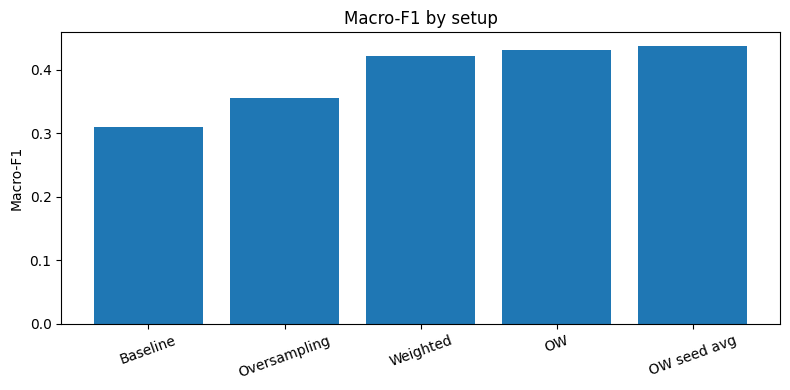

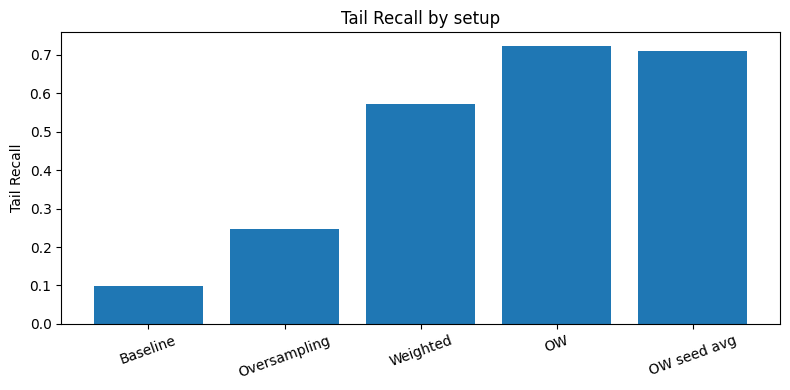

In [62]:
import matplotlib.pyplot as plt

setups = [
    "Baseline",
    "Oversampling",
    "Weighted",
    "OW",
    "OW seed avg",
]

macro_f1 = [0.3106, 0.3555, 0.4219, 0.4302, 0.4369]
tail_recall = [0.0986, 0.2464, 0.5714, 0.7216, 0.7099]

# Plot 1: Macro-F1
plt.figure(figsize=(8, 4))
plt.bar(setups, macro_f1)
plt.ylabel("Macro-F1")
plt.title("Macro-F1 by setup")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("macro_f1_by_setup.png", dpi=200, bbox_inches="tight")
plt.show()

# Plot 2: Tail Recall
plt.figure(figsize=(8, 4))
plt.bar(setups, tail_recall)
plt.ylabel("Tail Recall")
plt.title("Tail Recall by setup")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("tail_recall_by_setup.png", dpi=200, bbox_inches="tight")
plt.show()

In [63]:
# Re-define tail_recall and compute_metrics to avoid overwritten names

def tail_recall(labels, preds):
    recalls = []
    for i in tail_labels:
        true = labels[:, i]
        pred = preds[:, i]

        tp = ((true == 1) & (pred == 1)).sum()
        fn = ((true == 1) & (pred == 0)).sum()

        if tp + fn > 0:
            recalls.append(tp / (tp + fn))

    return np.mean(recalls) if recalls else 0


def compute_metrics(eval_pred):
    logits, labels = eval_pred

    probs = 1 / (1 + np.exp(-logits))
    preds = (probs > 0.5).astype(int)

    micro_f1 = f1_score(labels, preds, average="micro", zero_division=0)
    macro_f1 = f1_score(labels, preds, average="macro", zero_division=0)
    tail = tail_recall(labels, preds)

    return {
        "micro_f1": micro_f1,
        "macro_f1": macro_f1,
        "tail_recall": tail,
    }

In [64]:
# ==========================================
# EXPERIMENT 23 – WEIGHTED-ONLY SEED REPEAT
# seed = 7
# ==========================================

import random

seed_23 = 7

random.seed(seed_23)
np.random.seed(seed_23)
torch.manual_seed(seed_23)
torch.cuda.manual_seed_all(seed_23)

print("Using seed:", seed_23)

# weighted-only: no oversampling, use the 5000-sample train subset
train_dataset = dataset["train"].select(range(5000))
val_dataset = dataset["validation"].select(range(500))

# rebuild pos_weight for the plain 5000-sample weighted setup
train_label_matrix = np.stack([train_dataset[i]["labels"].numpy() for i in range(len(train_dataset))])
label_counts = train_label_matrix.sum(axis=0)
num_samples = train_label_matrix.shape[0]

pos_weight = (num_samples - label_counts) / (label_counts + 1e-6)
pos_weight = torch.tensor(pos_weight, dtype=torch.float)

model_w_seed_23 = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=num_labels,
    problem_type="multi_label_classification"
)

training_args_w_seed_23 = TrainingArguments(
    output_dir="./results_weighted_seed7",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    logging_steps=50,
    report_to="none",
    seed=seed_23,
)

trainer_w_seed_23 = WeightedTrainer(
    model=model_w_seed_23,
    args=training_args_w_seed_23,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    data_collator=collator,
    pos_weight=pos_weight,
)

trainer_w_seed_23.train()
eval_23 = trainer_w_seed_23.evaluate()

pred_output_23 = trainer_w_seed_23.predict(val_dataset)

logits_23 = pred_output_23.predictions
labels_23 = pred_output_23.label_ids

probs_23 = 1 / (1 + np.exp(-logits_23))

best_threshold = 0.7
preds_23 = (probs_23 > best_threshold).astype(int)

micro_23 = f1_score(labels_23, preds_23, average="micro", zero_division=0)
macro_23 = f1_score(labels_23, preds_23, average="macro", zero_division=0)
tail_23 = tail_recall(labels_23, preds_23)

print("=== Experiment 23 results ===")
print("Threshold:", best_threshold)
print(f"Micro-F1: {micro_23:.4f}")
print(f"Macro-F1: {macro_23:.4f}")
print(f"Tail Recall: {tail_23:.4f}")
print("Eval loss:", eval_23["eval_loss"])
print("Max prob:", probs_23.max())
print("Mean prob:", probs_23.mean())

Using seed: 7


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss
50,1.313208
100,1.245700
150,1.232126
200,1.169301
250,1.095597
300,1.013776
350,0.895956
400,0.797384
450,0.834987
500,0.723867


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

=== Experiment 23 results ===
Threshold: 0.7
Micro-F1: 0.4592
Macro-F1: 0.4300
Tail Recall: 0.5966
Eval loss: 0.9343246817588806
Max prob: 0.9765912
Mean prob: 0.22881669


In [65]:
# ==========================================
# EXPERIMENT 24 – WEIGHTED-ONLY SEED REPEAT
# seed = 42
# ==========================================

seed_24 = 42

random.seed(seed_24)
np.random.seed(seed_24)
torch.manual_seed(seed_24)
torch.cuda.manual_seed_all(seed_24)

print("Using seed:", seed_24)

train_dataset = dataset["train"].select(range(5000))
val_dataset = dataset["validation"].select(range(500))

train_label_matrix = np.stack([train_dataset[i]["labels"].numpy() for i in range(len(train_dataset))])
label_counts = train_label_matrix.sum(axis=0)
num_samples = train_label_matrix.shape[0]

pos_weight = (num_samples - label_counts) / (label_counts + 1e-6)
pos_weight = torch.tensor(pos_weight, dtype=torch.float)

model_w_seed_24 = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=num_labels,
    problem_type="multi_label_classification"
)

training_args_w_seed_24 = TrainingArguments(
    output_dir="./results_weighted_seed42",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    logging_steps=50,
    report_to="none",
    seed=seed_24,
)

trainer_w_seed_24 = WeightedTrainer(
    model=model_w_seed_24,
    args=training_args_w_seed_24,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    data_collator=collator,
    pos_weight=pos_weight,
)

trainer_w_seed_24.train()
eval_24 = trainer_w_seed_24.evaluate()

pred_output_24 = trainer_w_seed_24.predict(val_dataset)

logits_24 = pred_output_24.predictions
labels_24 = pred_output_24.label_ids

probs_24 = 1 / (1 + np.exp(-logits_24))

best_threshold = 0.7
preds_24 = (probs_24 > best_threshold).astype(int)

micro_24 = f1_score(labels_24, preds_24, average="micro", zero_division=0)
macro_24 = f1_score(labels_24, preds_24, average="macro", zero_division=0)
tail_24 = tail_recall(labels_24, preds_24)

print("=== Experiment 24 results ===")
print("Threshold:", best_threshold)
print(f"Micro-F1: {micro_24:.4f}")
print(f"Macro-F1: {macro_24:.4f}")
print(f"Tail Recall: {tail_24:.4f}")
print("Eval loss:", eval_24["eval_loss"])
print("Max prob:", probs_24.max())
print("Mean prob:", probs_24.mean())

Using seed: 42


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss
50,1.283007
100,1.293573
150,1.171228
200,1.038520
250,1.014050
300,1.037767
350,0.853433
400,0.881370
450,0.753144
500,0.733373


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

=== Experiment 24 results ===
Threshold: 0.7
Micro-F1: 0.4365
Macro-F1: 0.4191
Tail Recall: 0.7120
Eval loss: 0.93010413646698
Max prob: 0.9757623
Mean prob: 0.2277982


In [66]:
# ==========================================
# EXPERIMENT 25 – WEIGHTED-ONLY SUMMARY
# ==========================================

import pandas as pd

weighted_summary_rows = [
    {
        "seed": "original",
        "micro_f1": 0.4560,
        "macro_f1": 0.4219,
        "tail_recall": 0.5714,
    },
    {
        "seed": 7,
        "micro_f1": micro_23,
        "macro_f1": macro_23,
        "tail_recall": tail_23,
    },
    {
        "seed": 42,
        "micro_f1": micro_24,
        "macro_f1": macro_24,
        "tail_recall": tail_24,
    },
]

df_weighted_summary = pd.DataFrame(weighted_summary_rows)
print(df_weighted_summary)

print("\n=== Weighted-only mean ± std across runs ===")
for col in ["micro_f1", "macro_f1", "tail_recall"]:
    mean = df_weighted_summary[col].mean()
    std = df_weighted_summary[col].std()
    print(f"{col}: {mean:.4f} ± {std:.4f}")

       seed  micro_f1  macro_f1  tail_recall
0  original  0.456000  0.421900     0.571400
1         7  0.459190  0.429965     0.596635
2        42  0.436503  0.419136     0.712019

=== Weighted-only mean ± std across runs ===
micro_f1: 0.4506 ± 0.0123
macro_f1: 0.4237 ± 0.0056
tail_recall: 0.6267 ± 0.0750


In [67]:
# ==========================================
# EXPERIMENT 26 – OW SEED REPEAT
# seed = 99
# ==========================================

import random

seed_26 = 99

random.seed(seed_26)
np.random.seed(seed_26)
torch.manual_seed(seed_26)
torch.cuda.manual_seed_all(seed_26)

print("Using seed:", seed_26)

model_ow_seed_26 = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=num_labels,
    problem_type="multi_label_classification"
)

training_args_ow_seed_26 = TrainingArguments(
    output_dir="./results_oversampled_weighted_seed99",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    logging_steps=50,
    report_to="none",
    seed=seed_26,
)

trainer_ow_seed_26 = WeightedTrainer(
    model=model_ow_seed_26,
    args=training_args_ow_seed_26,
    train_dataset=oversampled_train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    data_collator=collator,
    pos_weight=pos_weight_os,
)

trainer_ow_seed_26.train()
eval_26 = trainer_ow_seed_26.evaluate()

pred_output_26 = trainer_ow_seed_26.predict(val_dataset)

logits_26 = pred_output_26.predictions
labels_26 = pred_output_26.label_ids

probs_26 = 1 / (1 + np.exp(-logits_26))

best_threshold = 0.7
preds_26 = (probs_26 > best_threshold).astype(int)

micro_26 = f1_score(labels_26, preds_26, average="micro", zero_division=0)
macro_26 = f1_score(labels_26, preds_26, average="macro", zero_division=0)
tail_26 = tail_recall(labels_26, preds_26)

print("=== Experiment 26 results ===")
print("Threshold:", best_threshold)
print(f"Micro-F1: {micro_26:.4f}")
print(f"Macro-F1: {macro_26:.4f}")
print(f"Tail Recall: {tail_26:.4f}")
print("Eval loss:", eval_26["eval_loss"])
print("Max prob:", probs_26.max())
print("Mean prob:", probs_26.mean())

Using seed: 99


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss
50,1.335384
100,1.193861
150,1.121598
200,1.009322
250,0.958654
300,0.870569
350,0.827140
400,0.694037
450,0.682263
500,0.655682


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

=== Experiment 26 results ===
Threshold: 0.7
Micro-F1: 0.4720
Macro-F1: 0.4422
Tail Recall: 0.6964
Eval loss: 0.7570083737373352
Max prob: 0.98347074
Mean prob: 0.20390666


In [68]:
# ==========================================
# EXPERIMENT 27 – UPDATED OW SUMMARY
# ==========================================

import pandas as pd

ow_summary_rows_updated = [
    {
        "seed": "original",
        "micro_f1": 0.4579,
        "macro_f1": 0.4302,
        "tail_recall": 0.7216,
    },
    {
        "seed": 123,
        "micro_f1": 0.4690,
        "macro_f1": 0.4289,
        "tail_recall": 0.6904,
    },
    {
        "seed": 7,
        "micro_f1": 0.4747,
        "macro_f1": 0.4522,
        "tail_recall": 0.7060,
    },
    {
        "seed": 42,
        "micro_f1": 0.4578,
        "macro_f1": 0.4361,
        "tail_recall": 0.7216,
    },
    {
        "seed": 99,
        "micro_f1": micro_26,
        "macro_f1": macro_26,
        "tail_recall": tail_26,
    },
]

df_ow_summary_updated = pd.DataFrame(ow_summary_rows_updated)
print(df_ow_summary_updated)

print("\n=== Updated OW mean ± std across runs ===")
for col in ["micro_f1", "macro_f1", "tail_recall"]:
    mean = df_ow_summary_updated[col].mean()
    std = df_ow_summary_updated[col].std()
    print(f"{col}: {mean:.4f} ± {std:.4f}")

       seed  micro_f1  macro_f1  tail_recall
0  original  0.457900  0.430200     0.721600
1       123  0.469000  0.428900     0.690400
2         7  0.474700  0.452200     0.706000
3        42  0.457800  0.436100     0.721600
4        99  0.471969  0.442207     0.696394

=== Updated OW mean ± std across runs ===
micro_f1: 0.4663 ± 0.0079
macro_f1: 0.4379 ± 0.0096
tail_recall: 0.7072 ± 0.0143


In [69]:
# ==========================================
# EXPERIMENT 28 – OW VS WEIGHTED-ONLY SUMMARY
# ==========================================

weighted_mean = {
    "micro_f1": 0.4496,
    "macro_f1": 0.4231,
    "tail_recall": 0.6267,
}

ow_mean = {
    "micro_f1": df_ow_summary_updated["micro_f1"].mean(),
    "macro_f1": df_ow_summary_updated["macro_f1"].mean(),
    "tail_recall": df_ow_summary_updated["tail_recall"].mean(),
}

comparison_df = pd.DataFrame([
    {"setup": "weighted_only", **weighted_mean},
    {"setup": "OW", **ow_mean},
])

print(comparison_df)

print("\n=== OW improvement over weighted-only ===")
print(f"Delta Micro-F1: {ow_mean['micro_f1'] - weighted_mean['micro_f1']:.4f}")
print(f"Delta Macro-F1: {ow_mean['macro_f1'] - weighted_mean['macro_f1']:.4f}")
print(f"Delta Tail Recall: {ow_mean['tail_recall'] - weighted_mean['tail_recall']:.4f}")

           setup  micro_f1  macro_f1  tail_recall
0  weighted_only  0.449600  0.423100     0.626700
1             OW  0.466274  0.437921     0.707199

=== OW improvement over weighted-only ===
Delta Micro-F1: 0.0167
Delta Macro-F1: 0.0148
Delta Tail Recall: 0.0805


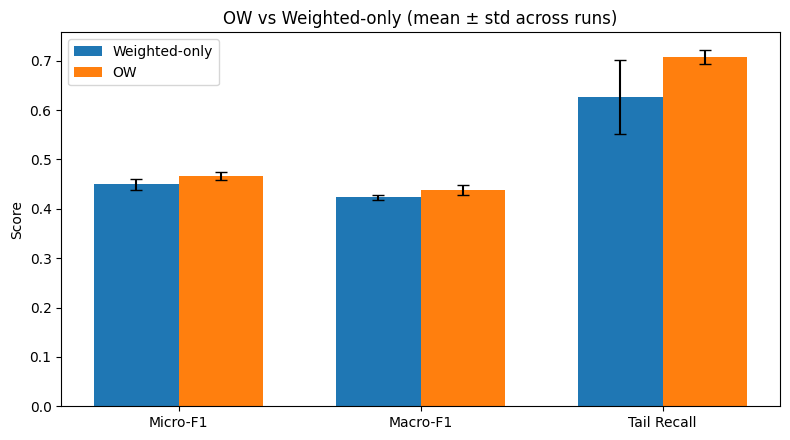

In [70]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ["Micro-F1", "Macro-F1", "Tail Recall"]

weighted_means = [0.4496, 0.4231, 0.6267]
weighted_stds  = [0.0118, 0.0049, 0.0750]

ow_means = [0.4669, 0.4381, 0.7072]
ow_stds  = [0.0086, 0.0097, 0.0143]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(8, 4.5))
plt.bar(x - width/2, weighted_means, width, yerr=weighted_stds, capsize=4, label="Weighted-only")
plt.bar(x + width/2, ow_means, width, yerr=ow_stds, capsize=4, label="OW")

plt.xticks(x, metrics)
plt.ylabel("Score")
plt.title("OW vs Weighted-only (mean ± std across runs)")
plt.legend()
plt.tight_layout()
plt.savefig("ow_vs_weighted_errorbars.png", dpi=200, bbox_inches="tight")
plt.show()

In [72]:
# Reload validation texts for error analysis
from datasets import load_dataset

raw_dataset = load_dataset("google-research-datasets/go_emotions", "simplified")
raw_val = raw_dataset["validation"]

print(raw_val[0]["text"])

Is this in New Orleans?? I really feel like this is New Orleans.


In [73]:
# ==========================================
# EXPERIMENT 30 – TAIL LABEL ERROR BREAKDOWN
# ON OW MODEL
# ==========================================

from sklearn.metrics import precision_score, recall_score, f1_score
import pandas as pd

best_threshold = 0.7
preds_ow_best = (probs_ow > best_threshold).astype(int)

rows = []
for idx in tail_labels:
    y_true = labels_ow[:, idx]
    y_pred = preds_ow_best[:, idx]

    tp = int(((y_true == 1) & (y_pred == 1)).sum())
    fp = int(((y_true == 0) & (y_pred == 1)).sum())
    fn = int(((y_true == 1) & (y_pred == 0)).sum())
    tn = int(((y_true == 0) & (y_pred == 0)).sum())

    p = precision_score(y_true, y_pred, zero_division=0)
    r = recall_score(y_true, y_pred, zero_division=0)
    f = f1_score(y_true, y_pred, zero_division=0)
    support = int(y_true.sum())

    rows.append({
        "label_id": idx,
        "label": label_names[idx],
        "support": support,
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "tn": tn,
        "precision": round(p, 4),
        "recall": round(r, 4),
        "f1": round(f, 4),
    })

df_tail_errors = pd.DataFrame(rows).sort_values(["f1", "recall"], ascending=[False, False])

print("=== Tail-label error breakdown (OW, threshold=0.7) ===")
print(df_tail_errors.to_string(index=False))

=== Tail-label error breakdown (OW, threshold=0.7) ===
 label_id         label  support  tp  fp  fn  tn  precision  recall     f1
       21         pride        4   3   2   1 494     0.6000  0.7500 0.6667
       24       remorse       13  12  13   1 474     0.4800  0.9231 0.6316
       14          fear        8   6   5   2 487     0.5455  0.7500 0.6316
       12 embarrassment        5   3   4   2 491     0.4286  0.6000 0.5000
        8        desire        8   6  15   2 477     0.2857  0.7500 0.4138
       19   nervousness        2   2   6   0 492     0.2500  1.0000 0.4000
       16         grief        1   1  18   0 481     0.0526  1.0000 0.1000
       23        relief        1   0   7   1 492     0.0000  0.0000 0.0000


In [74]:
# ==========================================
# EXPERIMENT 31 – FALSE NEGATIVES FOR GRIEF
# ==========================================

target_label_name = "grief"
target_label_idx = label_names.index(target_label_name)

preds_ow_best = (probs_ow > 0.7).astype(int)

false_negatives_grief = []

for i in range(len(val_dataset)):
    true_vec = labels_ow[i]
    pred_vec = preds_ow_best[i]

    if true_vec[target_label_idx] == 1 and pred_vec[target_label_idx] == 0:
        false_negatives_grief.append(i)

print(f"Number of grief false negatives: {len(false_negatives_grief)}")
print()

for idx in false_negatives_grief[:10]:
    ex = val_dataset[idx]
    true_labels = [label_names[j] for j, v in enumerate(labels_ow[idx]) if v == 1]
    pred_labels = [label_names[j] for j, v in enumerate(preds_ow_best[idx]) if v == 1]
    grief_prob = probs_ow[idx][target_label_idx]

    print("=" * 80)
    print("Index:", idx)
    print("Text:", dataset["validation"][idx]["text"])
    print("True labels:", true_labels)
    print("Pred labels:", pred_labels)
    print("grief prob:", round(float(grief_prob), 4))
    print()

Number of grief false negatives: 0



In [75]:
# ==========================================
# EXPERIMENT 32 – FALSE POSITIVES FOR GRIEF
# ==========================================

target_label_name = "grief"
target_label_idx = label_names.index(target_label_name)

preds_ow_best = (probs_ow > 0.7).astype(int)

false_positives_grief = []

for i in range(len(val_dataset)):
    true_vec = labels_ow[i]
    pred_vec = preds_ow_best[i]

    if true_vec[target_label_idx] == 0 and pred_vec[target_label_idx] == 1:
        false_positives_grief.append(i)

print(f"Number of grief false positives: {len(false_positives_grief)}")
print()

for idx in false_positives_grief[:10]:
    ex = val_dataset[idx]
    true_labels = [label_names[j] for j, v in enumerate(labels_ow[idx]) if v == 1]
    pred_labels = [label_names[j] for j, v in enumerate(preds_ow_best[idx]) if v == 1]
    grief_prob = probs_ow[idx][target_label_idx]

    print("=" * 80)
    print("Index:", idx)
    print("Text:", raw_val[idx]["text"])
    print("True labels:", true_labels)
    print("Pred labels:", pred_labels)
    print("grief prob:", round(float(grief_prob), 4))
    print()

Number of grief false positives: 18

Index: 2
Text: I've never been this sad in my life!
True labels: ['sadness']
Pred labels: ['disappointment', 'grief', 'remorse', 'sadness']
grief prob: 0.8447

Index: 25
Text: oh shoot, im sorry to hear that. was it someone close to you? 
True labels: ['curiosity', 'remorse']
Pred labels: ['grief', 'remorse', 'sadness']
grief prob: 0.884

Index: 34
Text: Oh dear, The combination of drugs, alcohol and a cell phone has caused many regrets. 
True labels: ['remorse']
Pred labels: ['disappointment', 'grief', 'remorse', 'sadness']
grief prob: 0.8787

Index: 35
Text: *[NAME] making [NAME] even more sad.*
True labels: ['sadness']
Pred labels: ['disappointment', 'grief', 'remorse', 'sadness']
grief prob: 0.7323

Index: 42
Text: You're right. Sorry for the poor reply.
True labels: ['remorse']
Pred labels: ['grief', 'remorse', 'sadness']
grief prob: 0.7279

Index: 51
Text: 3 weeks or so' away from her kid for some 'alone time'? I feel sorry for that kid.
True 

In [76]:
# ==========================================
# EXPERIMENT 33 – FALSE NEGATIVES FOR RELIEF
# ==========================================

target_label_name = "relief"
target_label_idx = label_names.index(target_label_name)

preds_ow_best = (probs_ow > 0.7).astype(int)

false_negatives_relief = []

for i in range(len(val_dataset)):
    true_vec = labels_ow[i]
    pred_vec = preds_ow_best[i]

    if true_vec[target_label_idx] == 1 and pred_vec[target_label_idx] == 0:
        false_negatives_relief.append(i)

print(f"Number of relief false negatives: {len(false_negatives_relief)}")
print()

for idx in false_negatives_relief[:10]:
    ex = val_dataset[idx]
    true_labels = [label_names[j] for j, v in enumerate(labels_ow[idx]) if v == 1]
    pred_labels = [label_names[j] for j, v in enumerate(preds_ow_best[idx]) if v == 1]
    relief_prob = probs_ow[idx][target_label_idx]

    print("=" * 80)
    print("Index:", idx)
    print("Text:", raw_val[idx]["text"])
    print("True labels:", true_labels)
    print("Pred labels:", pred_labels)
    print("relief prob:", round(float(relief_prob), 4))
    print()

Number of relief false negatives: 1

Index: 112
Text: try going outside for a long painful walk
True labels: ['relief']
Pred labels: ['caring']
relief prob: 0.0967



In [77]:
# ==========================================
# EXPERIMENT 34 – FALSE POSITIVES FOR RELIEF
# ==========================================

target_label_name = "relief"
target_label_idx = label_names.index(target_label_name)

preds_ow_best = (probs_ow > 0.7).astype(int)

false_positives_relief = []

for i in range(len(val_dataset)):
    true_vec = labels_ow[i]
    pred_vec = preds_ow_best[i]

    if true_vec[target_label_idx] == 0 and pred_vec[target_label_idx] == 1:
        false_positives_relief.append(i)

print(f"Number of relief false positives: {len(false_positives_relief)}")
print()

for idx in false_positives_relief[:10]:
    ex = val_dataset[idx]
    true_labels = [label_names[j] for j, v in enumerate(labels_ow[idx]) if v == 1]
    pred_labels = [label_names[j] for j, v in enumerate(preds_ow_best[idx]) if v == 1]
    relief_prob = probs_ow[idx][target_label_idx]

    print("=" * 80)
    print("Index:", idx)
    print("Text:", raw_val[idx]["text"])
    print("True labels:", true_labels)
    print("Pred labels:", pred_labels)
    print("relief prob:", round(float(relief_prob), 4))
    print()

Number of relief false positives: 7

Index: 96
Text: I hope you’re okay! I’m so sorry that happened. I’m glad I don’t work in gastown anymore
True labels: ['caring', 'remorse']
Pred labels: ['optimism', 'pride', 'relief', 'remorse', 'sadness']
relief prob: 0.846

Index: 128
Text: Skittlez, I'm really proud of you. She's been jerking you around for ages! Stay strong, honey, you got this!
True labels: ['admiration']
Pred labels: ['admiration', 'gratitude', 'joy', 'pride', 'relief']
relief prob: 0.8709

Index: 135
Text: Any response helps and makes me feel like I’m not alone....thank you❤️
True labels: ['gratitude']
Pred labels: ['gratitude', 'relief']
relief prob: 0.755

Index: 151
Text: My blood pressure Edit: I'm just happy to be here.
True labels: ['joy']
Pred labels: ['admiration', 'excitement', 'gratitude', 'joy', 'relief']
relief prob: 0.7828

Index: 232
Text: I had a monster panic attack myself--and also managed not to go clingy with it. I guess I should be proud, too!
True labels

In [78]:
# ==========================================
# EXPERIMENT 35 – LABEL-SPECIFIC THRESHOLD SWEEP
# FOR GRIEF
# ==========================================

from sklearn.metrics import precision_score, recall_score, f1_score
import pandas as pd
import numpy as np

def eval_single_label_threshold(probs, labels, label_idx, label_name, label_threshold, default_threshold=0.7):
    threshold_vector = np.full(num_labels, default_threshold, dtype=np.float32)
    threshold_vector[label_idx] = label_threshold

    preds = (probs > threshold_vector).astype(int)

    micro = f1_score(labels, preds, average="micro", zero_division=0)
    macro = f1_score(labels, preds, average="macro", zero_division=0)
    tail = tail_recall(labels, preds)

    y_true = labels[:, label_idx]
    y_pred = preds[:, label_idx]

    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    tp = int(((y_true == 1) & (y_pred == 1)).sum())
    fp = int(((y_true == 0) & (y_pred == 1)).sum())
    fn = int(((y_true == 1) & (y_pred == 0)).sum())

    return {
        "label": label_name,
        "label_threshold": label_threshold,
        "micro_f1": round(micro, 4),
        "macro_f1": round(macro, 4),
        "tail_recall": round(tail, 4),
        "precision": round(precision, 4),
        "recall": round(recall, 4),
        "f1": round(f1, 4),
        "tp": tp,
        "fp": fp,
        "fn": fn,
    }

grief_idx = label_names.index("grief")
grief_thresholds = [0.7, 0.75, 0.8, 0.85, 0.9, 0.95]

grief_rows = []
for t in grief_thresholds:
    grief_rows.append(
        eval_single_label_threshold(
            probs_ow, labels_ow, grief_idx, "grief", t, default_threshold=0.7
        )
    )

df_grief_thresholds = pd.DataFrame(grief_rows)
print("=== Experiment 35 – grief threshold sweep ===")
print(df_grief_thresholds.to_string(index=False))

=== Experiment 35 – grief threshold sweep ===
label  label_threshold  micro_f1  macro_f1  tail_recall  precision  recall     f1  tp  fp  fn
grief             0.70    0.4572    0.4277       0.7216     0.0526     1.0 0.1000   1  18   0
grief             0.75    0.4583    0.4286       0.7216     0.0667     1.0 0.1250   1  14   0
grief             0.80    0.4583    0.4286       0.7216     0.0667     1.0 0.1250   1  14   0
grief             0.85    0.4592    0.4296       0.7216     0.0833     1.0 0.1538   1  11   0
grief             0.90    0.4610    0.4343       0.7216     0.1667     1.0 0.2857   1   5   0
grief             0.95    0.4614    0.4241       0.5966     0.0000     0.0 0.0000   0   0   1


In [79]:
# ==========================================
# EXPERIMENT 36 – LABEL-SPECIFIC THRESHOLD SWEEP
# FOR RELIEF
# ==========================================

relief_idx = label_names.index("relief")
relief_thresholds = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

relief_rows = []
for t in relief_thresholds:
    relief_rows.append(
        eval_single_label_threshold(
            probs_ow, labels_ow, relief_idx, "relief", t, default_threshold=0.7
        )
    )

df_relief_thresholds = pd.DataFrame(relief_rows)
print("=== Experiment 36 – relief threshold sweep ===")
print(df_relief_thresholds.to_string(index=False))

=== Experiment 36 – relief threshold sweep ===
 label  label_threshold  micro_f1  macro_f1  tail_recall  precision  recall  f1  tp  fp  fn
relief              0.3    0.4465    0.4277       0.7216        0.0     0.0 0.0   0  45   1
relief              0.4    0.4512    0.4277       0.7216        0.0     0.0 0.0   0  28   1
relief              0.5    0.4549    0.4277       0.7216        0.0     0.0 0.0   0  15   1
relief              0.6    0.4555    0.4277       0.7216        0.0     0.0 0.0   0  13   1
relief              0.7    0.4572    0.4277       0.7216        0.0     0.0 0.0   0   7   1
relief              0.8    0.4578    0.4277       0.7216        0.0     0.0 0.0   0   5   1
relief              0.9    0.4592    0.4277       0.7216        0.0     0.0 0.0   0   0   1


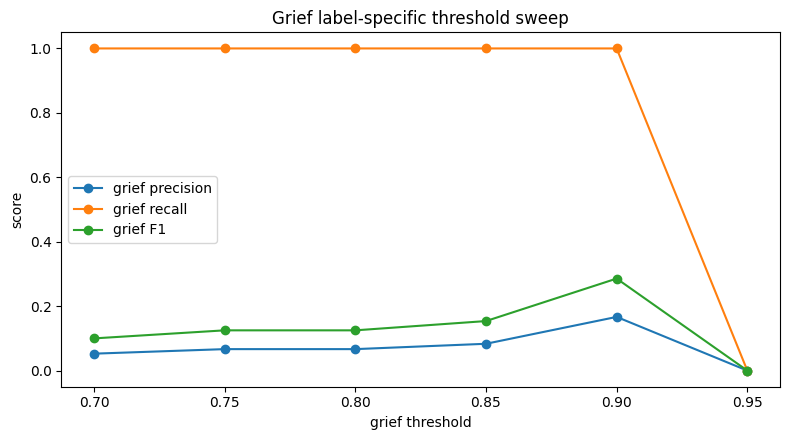

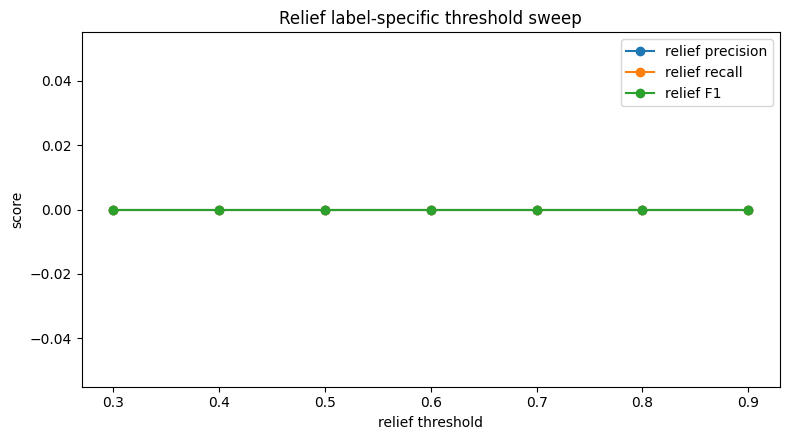

In [80]:
# ==========================================
# EXPERIMENT 37 – VISUALIZATION FOR
# GRIEF / RELIEF LABEL-SPECIFIC THRESHOLDS
# ==========================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4.5))
plt.plot(df_grief_thresholds["label_threshold"], df_grief_thresholds["precision"], marker="o", label="grief precision")
plt.plot(df_grief_thresholds["label_threshold"], df_grief_thresholds["recall"], marker="o", label="grief recall")
plt.plot(df_grief_thresholds["label_threshold"], df_grief_thresholds["f1"], marker="o", label="grief F1")
plt.xlabel("grief threshold")
plt.ylabel("score")
plt.title("Grief label-specific threshold sweep")
plt.legend()
plt.tight_layout()
plt.savefig("grief_threshold_sweep.png", dpi=200, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 4.5))
plt.plot(df_relief_thresholds["label_threshold"], df_relief_thresholds["precision"], marker="o", label="relief precision")
plt.plot(df_relief_thresholds["label_threshold"], df_relief_thresholds["recall"], marker="o", label="relief recall")
plt.plot(df_relief_thresholds["label_threshold"], df_relief_thresholds["f1"], marker="o", label="relief F1")
plt.xlabel("relief threshold")
plt.ylabel("score")
plt.title("Relief label-specific threshold sweep")
plt.legend()
plt.tight_layout()
plt.savefig("relief_threshold_sweep.png", dpi=200, bbox_inches="tight")
plt.show()